In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

In [11]:
df = pd.read_csv(r'C:\Users\potha\Downloads\archive\tested.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [19]:
df.info() #understanding the data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [ ]:
df.describe() #Understand distribution, scale, outliers

>Missing Values Analysis

missing_count = df.isnull().sum()    #Identify data quality issues by using missing values
missing_percent = (missing_count / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percent
}).sort_values(by="Missing Percentage", ascending=False)

missing_df


>Numerical Feature Distributions:Age Distribution,Fare Distribution

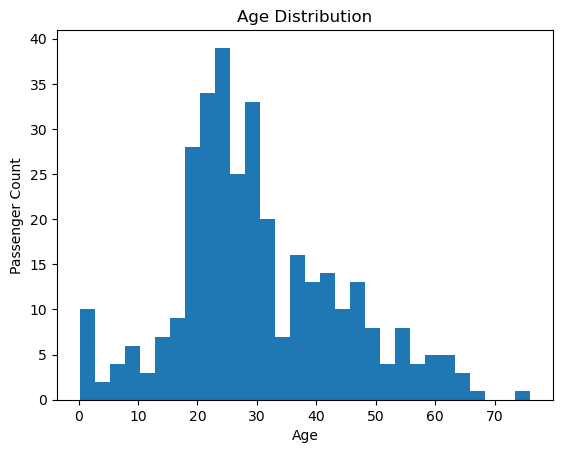

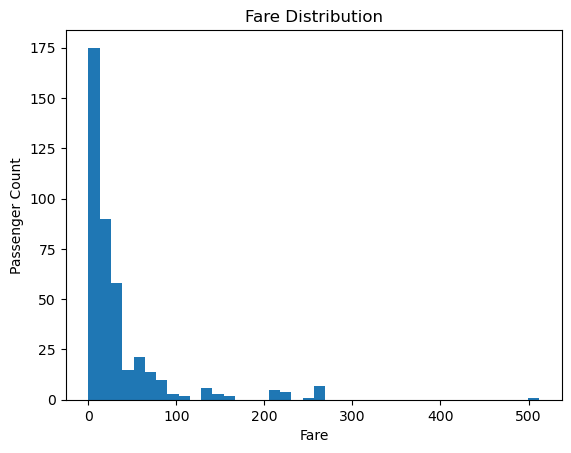

In [39]:
plt.hist(df['Age'].dropna(), bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Passenger Count")
plt.show()

plt.hist(df['Fare'], bins=40)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Passenger Count")
plt.show()



>Categorical Feature Analysis:Gender Count,Embarkation Port and Passenger Class

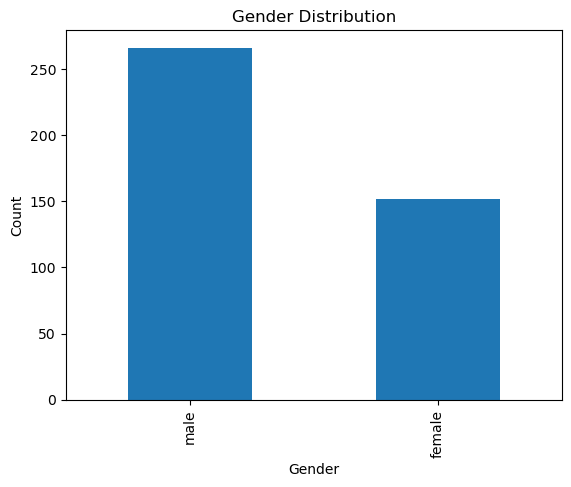

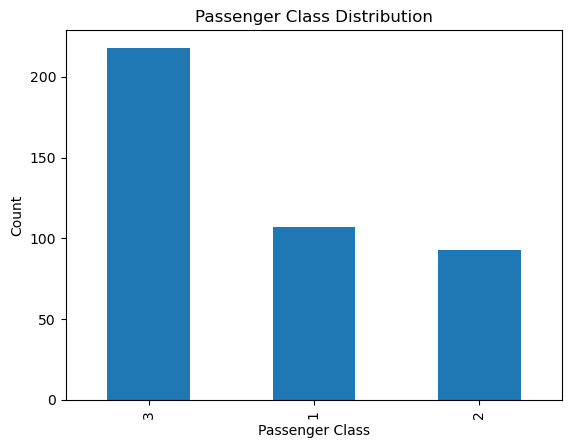

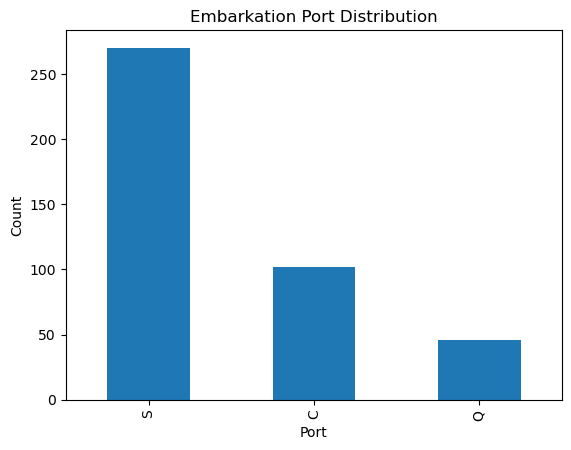

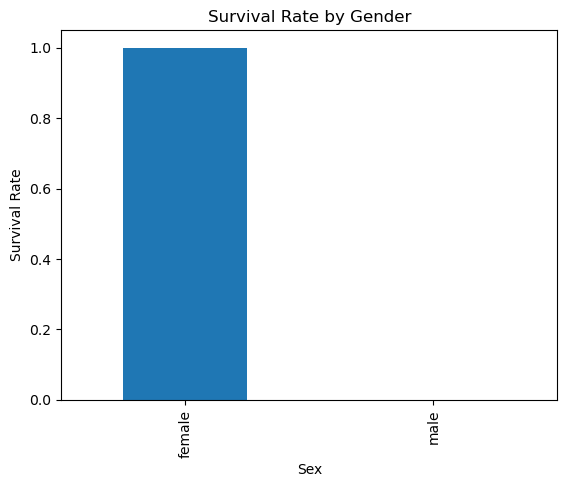

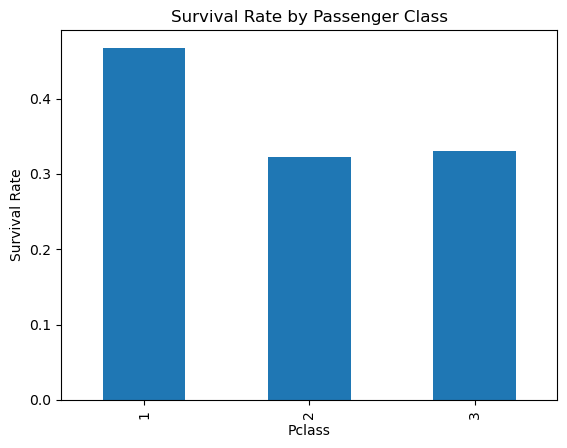

In [45]:
df['Sex'].value_counts().plot(kind='bar')
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

df['Pclass'].value_counts().plot(kind='bar')
plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.show()

df['Embarked'].value_counts().plot(kind='bar')
plt.title("Embarkation Port Distribution")
plt.xlabel("Port")
plt.ylabel("Count")
plt.show()

df.groupby('Sex')['Survived'].mean().plot(kind='bar')
plt.title("Survival Rate by Gender")
plt.ylabel("Survival Rate")
plt.show()

df.groupby('Pclass')['Survived'].mean().plot(kind='bar')
plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate")
plt.show()


>Family Information Analysis:Family size feature

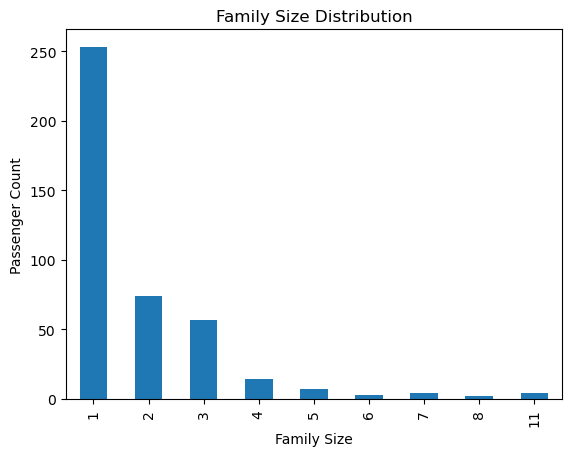

In [41]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

df['FamilySize'].value_counts().sort_index().plot(kind='bar')
plt.title("Family Size Distribution")
plt.xlabel("Family Size")
plt.ylabel("Passenger Count")
plt.show()


>OUTLIER DETECTION

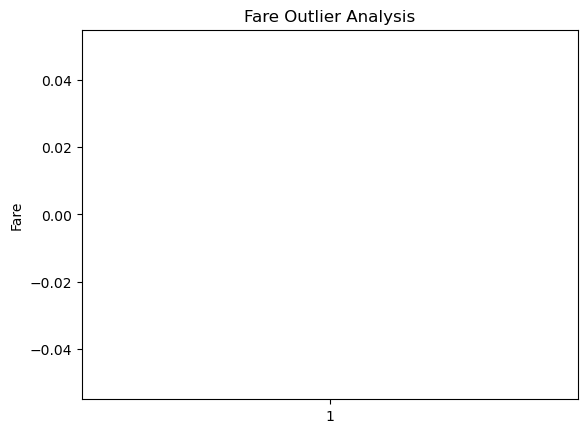

In [43]:
plt.boxplot(df['Fare'])
plt.title("Fare Outlier Analysis")
plt.ylabel("Fare")
plt.show()


>CORRELATION ANALYSIS(NUMERICAL FEATURES)

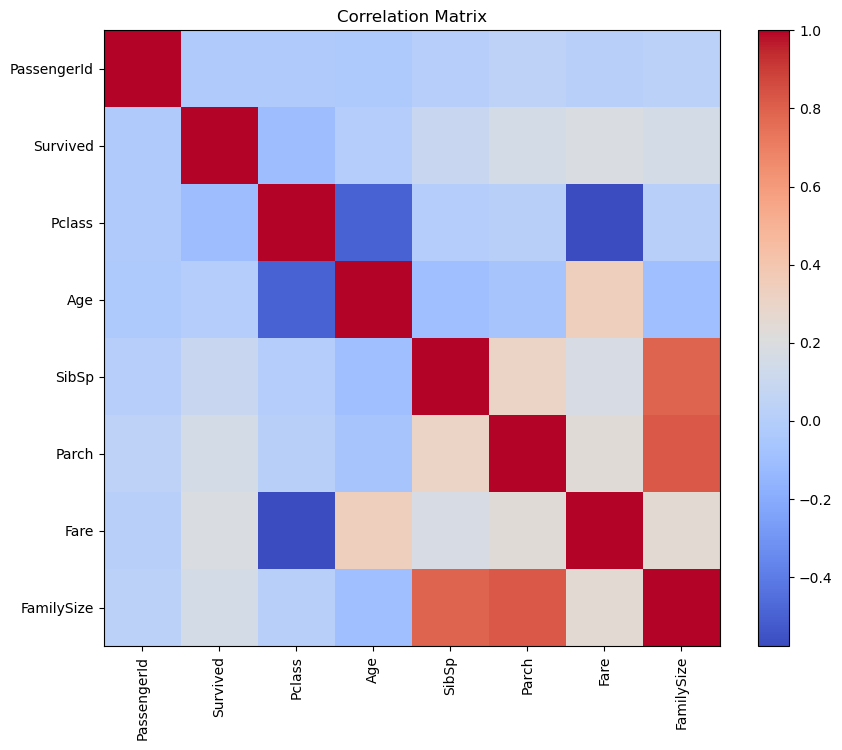

In [38]:
corr_matrix = df.select_dtypes(include='number').corr()

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap='coolwarm')
plt.colorbar()

plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Correlation Matrix")
plt.show()

